<a href="https://colab.research.google.com/github/AdwaiT-ctrl/NN-programming-tutorials/blob/main/Programming_Tutorial_7_Residual_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programming Tutorial 7: Residual Networks

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```


## Overview

**Sections**:
- Skip connections
- Residual network
- Experiments: model training with/without skip connections
- Pretrained ResNet

**Objectives**:
- Learn how to build a residual block with skip connections
- Learn how to build a residual network using residual blocks
- Compare the model performances with and without skip connections
- Learn how to load a pretrained ResNet from PyTorch and print the top n predictions of an image


Today's tutorial requires GPU computation resource. If you haven't done so yet, check the runtime type:

**Runtime** -> **Change runtime type** --> **GPU** (e.g., T4 GPU)

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T

## Residual/Skip Connection

We learned about residual/skip connections in the model ResNet in the lecture. Today, we'll be implementing residual models using Pytorch! Let's start simple - below, use the convolution layers, batch normalization layers, and skip/residual connections to build **a residual block**:

- [`nn.Conv2d`]()
- [`nn.BatchNorm2d`]()
- [`nn.functional.relu`]()

Design our residual block:

```
Conv(3x3) -> BN -> ReLU ->
Conv(3x3) -> BN -> (optional) skip add -> ReLU
* Use a projection (1x1 conv) when shape changes (stride or channels).
```

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # projection for skip connection
        # if shapes don't match, use 1x1 conv to adjust number of channels
        self.proj = None
        if stride != 1 or in_ch != out_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        identity = x # block input

        # layer 1: conv + bn + relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        # layer 2: conv + bn
        out = self.conv2(out)
        out = self.bn2(out)

        # skip connection
        if self.use_skip:
            # project the channels if needed
            if self.proj is not None:
                identity = self.proj(identity)
            # add connection
            out = out + identity

        # activation is applied after skip connection
        out = F.relu(out)
        return out

Print the block summary:

In [ ]:
!pip -q install torchinfo

In [ ]:
from torchinfo import summary

block = BasicBlock(in_ch=16, out_ch=16, stride=1, use_skip=True).to(device)
summary(block, input_size=(1, 16, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
BasicBlock                               [1, 16, 32, 32]           --
├─Conv2d: 1-1                            [1, 16, 32, 32]           2,304
├─BatchNorm2d: 1-2                       [1, 16, 32, 32]           32
├─Conv2d: 1-3                            [1, 16, 32, 32]           2,304
├─BatchNorm2d: 1-4                       [1, 16, 32, 32]           32
Total params: 4,672
Trainable params: 4,672
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.72
Input size (MB): 0.07
Forward/backward pass size (MB): 0.52
Params size (MB): 0.02
Estimated Total Size (MB): 0.61

**[Pause and Think]**

Try disabling the skip connection by using `use_skip=False`. Is there any change in the architecture or number of parameters? Why?

## Residual Network

**[Friendly Reminder from TA]**:

It is common to mix up **Recurrent Neural Networks (RNN)** and **Residual Network (ResNet)**. The two names might look similar, but they are two different models and have nothing to do with each other 😉

### Architecture

The most important component of the network, `BasicBlock`, is ready. Now, we'll use this block to build a neural network. For the experiments in this tutorial, we will continue to provide options for `use_skip`.

In this deep network, we'll adopt the ResNet spirit and implement multiple stages composed of residual blocks, and as it goes deeper, the number of channels increases:
- **Stage 1**: 16 channels with `n1` blocks
- **Stage 2**: 32 channels with `n2` blocks
- **Stage 3**: 64 channels with `n3` blocks

This design is sufficient for our experiment today, but you can increase the number of channels and/or stages to build a model that resembles ResNet.

Leaving the numbers of blocks, `n1`, `n2`, and `n3`, adjustable gives us flexibility for model depth.

In [ ]:
class DeepNetwork(nn.Module):
    """
    Stage layout (like a tiny ResNet):
    stem: 3x3 conv -> BN -> ReLU
    n_blocks: (n1, n2, n3)
    stage1: width=16, blocks=n1, stride=1
    stage2: width=32, blocks=n2, stride=2 (downsample)
    stage3: width=64, blocks=n3, stride=2 (downsample)
    head: global avg pool -> linear 10
    """
    def __init__(self, n_blocks=(3, 3, 3), use_skip=True, num_classes=10):
        super().__init__()
        self.use_skip = use_skip

        # First: apply the first conv layer
        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )

        # Second: connect the three stages with residual blocks
        self.stage1 = self._make_stage(16, 16, n_blocks[0], stride=1, use_skip=use_skip)
        self.stage2 = self._make_stage(16, 32, n_blocks[1], stride=2, use_skip=use_skip)
        self.stage3 = self._make_stage(32, 64, n_blocks[2], stride=2, use_skip=use_skip)

        # Third: connect features to classification
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(64, num_classes)

        self._init_weights()

    def _make_stage(self, in_ch, out_ch, n, stride, use_skip): # stack blocks
        blocks = []
        blocks.append(BasicBlock(in_ch, out_ch, stride=stride, use_skip=use_skip))
        for _ in range(n - 1):
            blocks.append(BasicBlock(out_ch, out_ch, stride=1, use_skip=use_skip))
        return nn.Sequential(*blocks)

    def _init_weights(self):
        # assign initialization methods
        # choose good default init for conv nets with BN
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = self.fc(x)
        return x


Print the summary using the model size, `n_blocks=(3,3,3)` and the image size, `(3, 32, 32)`.

In [ ]:
model = DeepNetwork(n_blocks=(3,3,3), use_skip=True).to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
DeepNetwork                              [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 16, 32, 32]           432
│    └─BatchNorm2d: 2-2                  [1, 16, 32, 32]           32
│    └─ReLU: 2-3                         [1, 16, 32, 32]           --
├─Sequential: 1-2                        [1, 16, 32, 32]           --
│    └─BasicBlock: 2-4                   [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-2             [1, 16, 32, 32]           32
│    │    └─Conv2d: 3-3                  [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-4             [1, 16, 32, 32]           32
│    └─BasicBlock: 2-5                   [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-5                  [1, 16, 32, 32]           2,304
│    

### Model Trainer

Let's build a trainer for our model, `DeepNetwork`.

Today, we'll be using [Adam optimizer](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html). This will help the model converge faster. Note that the mechanisms of optimizers can be different, meaning that learning rate or other hyperparameters might need some tweaking. For example, in the following training, `lr=0.1` works better for SGD optimizer while `lr=0.001` works better for Adam optimizer. You're encouraged to change these settings and compare the results.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * y.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


def train(model, train_loader, test_loader, epochs=20, lr=0.001, weight_decay=5e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        running_correct = 0
        n_seen = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                preds = logits.argmax(dim=1)
                running_correct += (preds == y).sum().item()
                running_loss += loss.item() * y.size(0)
                n_seen += y.size(0)

        train_loss = running_loss / n_seen
        train_acc = running_correct / n_seen

        test_loss, test_acc = evaluate(model, test_loader, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc*100:.2f}% | "
            f"test loss {test_loss:.4f} acc {test_acc*100:.2f}% | "
        )

    history = {
        "train_loss": train_losses,
        "train_acc": train_accs,
        "test_loss": test_losses,
        "test_acc": test_accs,
    }

    return model, history


## Experiments: Skip Connections *(Running Takes ~15 Minutes)*

In this section, we will load a dataset, create the `DeepNetwork` models, and train these models.

### Dataset

Today, we will be using the PyTorch built-in dataset, CIFAR10. To load the train set, you can use:
```
train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True)
```
To load the test set, you can use:
```
train_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True)
```
We will be talking about the PyTorch built-in datasets in the next tutorial, so stay tuned!

**[Image Normalization]**

In the last tutorial, we practiced how to use the image pre-processing tool, `torchvision.transforms`. Today, we'll be using the loaded dataset to calculate the `mean` and `std` for the normalization transform.

Note that for image data, we don't process pixels separately. Instead, we treat the entire color channel as a group. Therefore, we'll be calculating the `mean` and `std` values for the ***three*** color channels, red (R), green (G), and blue (B).

In [ ]:
# Load dataset
train_set_raw = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=T.ToTensor()
)

# Use data loader on the raw data
train_loader_raw = DataLoader(train_set_raw, batch_size=256, shuffle=False)

# Compute per-channel mean/std over the whole training set
sum_ = torch.zeros(3)
sum_sq = torch.zeros(3)
n_pixels = 0

# Compute batch by batch to prevent runtime crash
for x, _ in train_loader_raw:
    sum_ += x.sum(dim=(0, 2, 3))
    sum_sq += (x ** 2).sum(dim=(0, 2, 3))
    n_pixels += x.size(0) * x.size(2) * x.size(3)

# Print results
mean = sum_ / n_pixels
std = (sum_sq / n_pixels - mean ** 2).sqrt()
print("CIFAR-10 mean:", mean.tolist())
print("CIFAR-10 std: ", std.tolist())

CIFAR-10 mean: [0.4913996458053589, 0.48215845227241516, 0.4465310275554657]
CIFAR-10 std:  [0.2470323145389557, 0.24348507821559906, 0.26158758997917175]


Alternatively, it is common for the famous dataset to have documented means and standard deviations for their color channels. For large-scale datasets, it saves your time and computing power by trusting the reported values (from their website, published papers, or technical reports). You can hard code these values:

In [ ]:
# CIFAR-10 mean/std
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

Now, with the assigned pre-processing techniques, we will apply them to `transform=xxxx` when loading the data:

In [ ]:
# Pre-process data + augmentation
train_tfms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Do NOT add augmentation to test set
test_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# When loading the dataset, use the pre-processing transform
train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tfms)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tfms)

# Use data loader to divide data into batches
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = train_set.classes

### Training

Let's train the two models! One model has skip connections and the other doesn't. The models will be using the same depth structures for all stages.

In [ ]:
# set up depth
model_depth = (5,5,5)

# Same depth, only difference is skip connection
plain_model = DeepNetwork(n_blocks=model_depth, use_skip=False)  # no residual
res_model = DeepNetwork(n_blocks=model_depth, use_skip=True)   # with residual

# Train and print results
print("Training Plain Network (without skip connections):")
plain_model, plain_history = train(plain_model, train_loader, test_loader, epochs=10, lr=0.001)

print("\nTraining Residual Network (with skip connections):")
res_model, res_history= train(res_model, train_loader, test_loader, epochs=10, lr=0.001)

Training Plain Network (without skip connections):
Epoch 01/10 | train loss 1.8785 acc 26.44% | test loss 1.8499 acc 29.07% | 
Epoch 02/10 | train loss 1.6431 acc 36.70% | test loss 1.5235 acc 41.67% | 
Epoch 03/10 | train loss 1.4725 acc 45.09% | test loss 1.4591 acc 47.81% | 
Epoch 04/10 | train loss 1.3283 acc 51.80% | test loss 1.3015 acc 52.71% | 
Epoch 05/10 | train loss 1.2151 acc 56.24% | test loss 1.3424 acc 52.48% | 
Epoch 06/10 | train loss 1.1317 acc 59.44% | test loss 1.3474 acc 53.33% | 
Epoch 07/10 | train loss 1.0667 acc 61.96% | test loss 1.2183 acc 57.72% | 
Epoch 08/10 | train loss 1.0150 acc 63.79% | test loss 1.0400 acc 63.34% | 
Epoch 09/10 | train loss 0.9643 acc 65.42% | test loss 1.0383 acc 63.64% | 
Epoch 10/10 | train loss 0.9250 acc 66.97% | test loss 1.0398 acc 64.09% | 

Training Residual Network (with skip connections):
Epoch 01/10 | train loss 1.5971 acc 39.01% | test loss 1.5427 acc 45.09% | 
Epoch 02/10 | train loss 1.1803 acc 57.10% | test loss 1.1232

### Results Visualization

Plot the two models' training curves:

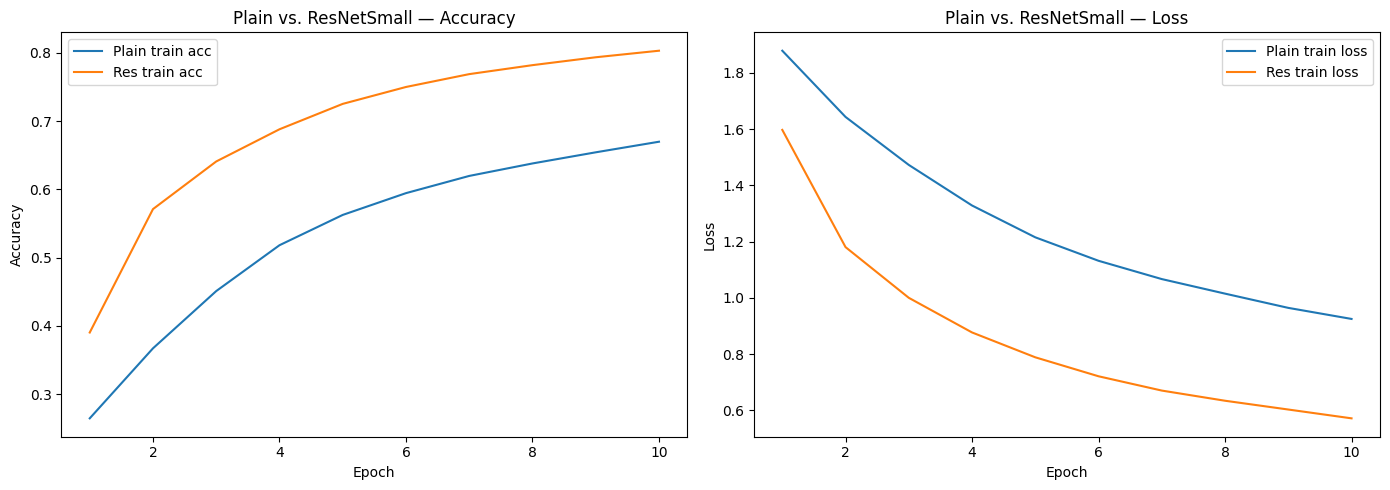

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(plain_history["train_loss"]) + 1)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axs[0].plot(epochs, plain_history["train_acc"], label="Plain train acc")
axs[0].plot(epochs, res_history["train_acc"],   label="Res train acc")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].set_title("Plain vs. ResNetSmall — Accuracy")
axs[0].legend()

# Loss plot
axs[1].plot(epochs, plain_history["train_loss"], label="Plain train loss")
axs[1].plot(epochs, res_history["train_loss"],   label="Res train loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].set_title("Plain vs. ResNetSmall — Loss")
axs[1].legend()

plt.tight_layout()
plt.show()

We can see that the skip connections added a significant boost to the performance!

## Pretrained ResNet

Similar to what we experimented with AlexNet, ResNet has pretrained models available on PyTorch for us to load directly.

- Read the tutorial: [PyTorch ResNet](https://pytorch.org/hub/pytorch_vision_resnet/)
- Read the documentation for ResNet model architectures and pre-trained weights on PyTorch: [documentation](https://docs.pytorch.org/vision/main/models/resnet.html)

We are able to see the versions, `resnet18`, `resnet34`, `resnet50`, `resnet101`, and `resnet152`. Let's load a `resnet50` default model:

In [ ]:
import torch
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)

# Use the recommended preprocessing for this pretrained model
preprocess = weights.transforms()

We can pull up an image and print the top 5 predictions from the model. Today, we'll try acquiring an image using a url instead of reading an image from a local path.

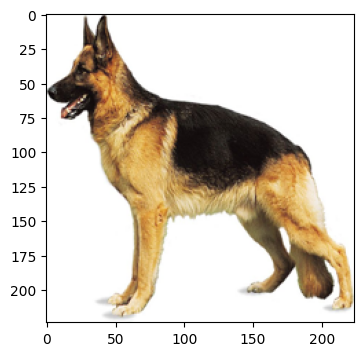

In [ ]:
from PIL import Image
from urllib import request
from io import BytesIO
import matplotlib.pyplot as plt

# Use an image URL (must end with .jpg)
url = "https://cdn.britannica.com/60/8160-050-08CCEABC/German-shepherd.jpg"
response = request.urlopen(url).read()
img = Image.open(BytesIO(response)).resize((224, 224))

# visualize image
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

Find the top five predicted probabilities and print the class names:

In [ ]:
model.eval()

# Preprocess image using the model default
x = preprocess(img)
x = x.unsqueeze(0).to(device)  # stack into a batch [1, 3, H, W]

# Predict
with torch.no_grad():
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    top5_prob, top5_idx = probs.topk(5, dim=1)

# Decode to human-readable labels
categories = weights.meta["categories"]
print("Top-5 predictions:")
for p, idx in zip(top5_prob[0].tolist(), top5_idx[0].tolist()):
    print(f"{categories[idx]:>25s}  prob={p:.4f}")

Top-5 predictions:
          German shepherd  prob=0.4645
                 malinois  prob=0.0153
                   muzzle  prob=0.0061
                limousine  prob=0.0035
         bulletproof vest  prob=0.0026


## Review

In this tutorial, we learned how to build skip connections in a residual block, and we used this residual block to design a full neural network with three CNN residual stages. The results show that the model with skip connections outperforms the one without skip connections.

For practice, you can try:
1. Creating a model with 5 stages and train it with skip connections. Compare the results with the model we have.
2. Use the technique we practiced in Programming Tutorial 6 to remove the final layer of the pretrained ResNet and change it to fit CIFAR10. Fine-tune the model on CIFAR10 and compare its converge time to the residual model we trained from scratch.


For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley